# Computing I Assignment 4
Kwatcho Mahinanda
10/8/2025

In [14]:
import pandas as pd
import plotly.express as px
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import re
import seaborn as sns
import warnings

In [ ]:
# Load data
df = pd.read_csv("bills_actions.csv")
print(f"Data loaded: {len(df):,} rows, {len(df.columns)} columns")
print(f"Columns: {', '.join(df.columns)}")

Data loaded: 3,303 rows, 7 columns
Columns: Congress, bill_number, bill_type, action, main_action, category, member_id


In [16]:
# Quality check
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("First 3 rows:")
print(df.head(3))

Missing Values:
Series([], dtype: int64)
First 3 rows:
   Congress  bill_number bill_type  \
0       116         1029         s   
1       116         1031         s   
2       116         1160         s   

                                              action  \
0  S.Amdt.1274 Amendment SA 1274 proposed by Sena...   
1  S.Amdt.2698 Amendment SA 2698 proposed by Sena...   
2  S.Amdt.2659 Amendment SA 2659 proposed by Sena...   

                                main_action   category  member_id  
0  senate amendment proposed (on the floor)  amendment        858  
1  senate amendment proposed (on the floor)  amendment        675  
2  senate amendment proposed (on the floor)  amendment        858  


### How many distint "bill" identifiers are there?

In [24]:
# Create a new column for a truly unique bill ID
df['bill_id'] = df['bill_type'] + df['bill_number'].astype(str)

# Now, count the unique values in this new column
num_unique_bills = df['bill_id'].nunique()

print(f"Number of distinct bill identifiers: {num_unique_bills}")

Number of distinct bill identifiers: 1494


### What proportion of the rows belong to different categories?

In [4]:
#Proportion of rows by category
category_proportions = df['category'].value_counts(normalize=True).reset_index()
category_proportions.columns = ['category_name', 'proportion']
print("\nProportion of rows by category:")
print(category_proportions)
print(category_proportions["proportion"].sum())



Proportion of rows by category:
                  category_name  proportion
0                     amendment    0.462913
1                    house bill    0.273085
2                   senate bill    0.155616
3              house resolution    0.070845
4             senate resolution    0.018165
5        house joint resolution    0.006661
6   house concurrent resolution    0.006055
7  senate concurrent resolution    0.004239
8       senate joint resolution    0.002422
1.0


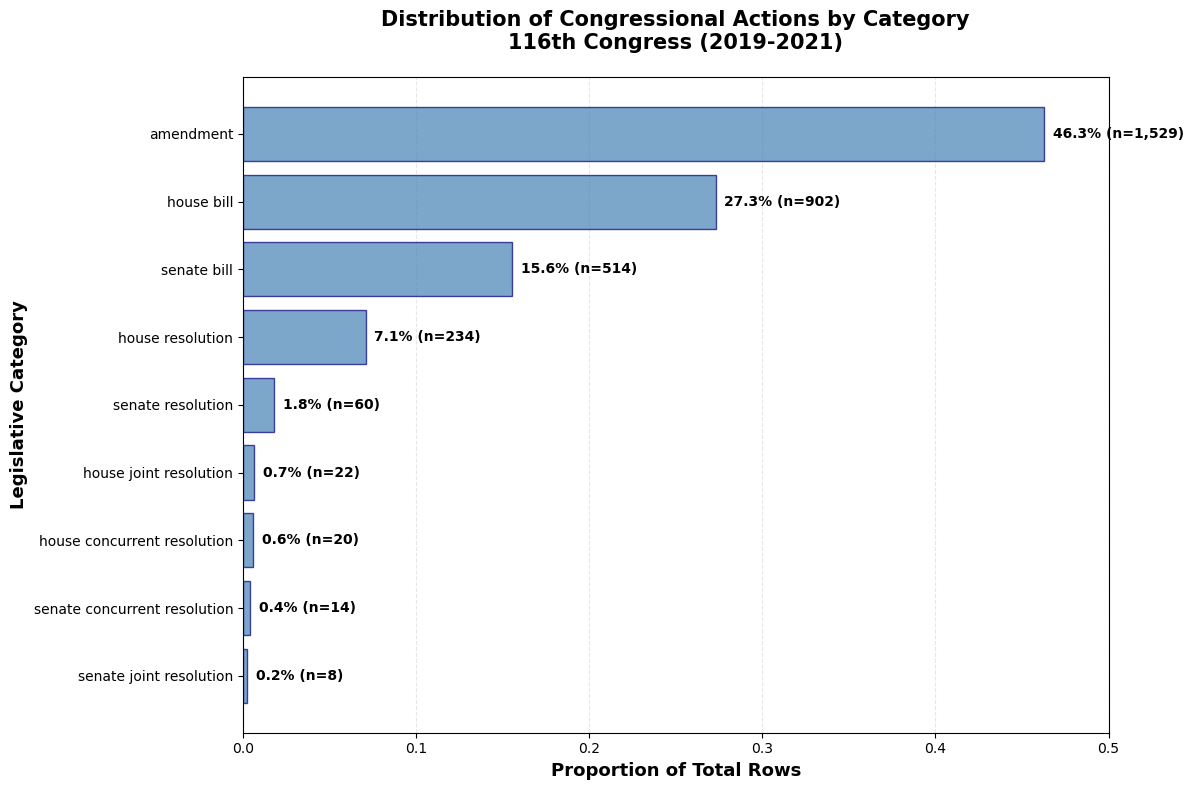

In [26]:
# Visualize category distribution
fig, ax = plt.subplots(figsize=(12, 8))
category_proportions_sorted = category_proportions.sort_values('proportion', ascending=True)
bars = ax.barh(category_proportions_sorted['category_name'], 
               category_proportions_sorted['proportion'],
               color='steelblue', edgecolor='navy', alpha=0.7)
ax.set_xlabel('Proportion of Total Rows', fontsize=13, fontweight='bold')
ax.set_ylabel('Legislative Category', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Congressional Actions by Category\n116th Congress (2019-2021)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlim(0, 0.5)

for i, (idx, row) in enumerate(category_proportions_sorted.iterrows()):
    count = (df['category'] == row['category_name']).sum()
    ax.text(row['proportion'] + 0.005, i, 
            f"{row['proportion']*100:.1f}% (n={count:,})", 
            va='center', fontsize=10, fontweight='bold')

ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### The proportion of rows that belongs to different “main_action” within each category

In [28]:
main_action_proportions = (
    df.groupby('category')['main_action']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)


for category in df['category'].unique():
    print(f"{category.upper()}:")
    category_data = main_action_proportions[main_action_proportions['category'] == category]
    category_data = category_data.sort_values('proportion', ascending=False).head(5)
    
    for idx, row in category_data.iterrows():
        count = ((df['category'] == category) & (df['main_action'] == row['main_action'])).sum()
        print(f"   {row['main_action']:.<50} {row['proportion']*100:>6.2f}% ({count:>4,} rows)")


AMENDMENT:
   house amendment offered...........................  54.15% ( 828 rows)
   other house amendment actions.....................  25.96% ( 397 rows)
   senate amendment proposed (on the floor)..........  18.71% ( 286 rows)
   other senate amendment actions....................   1.18% (  18 rows)
SENATE BILL:
   senate committee/subcommittee actions.............  65.18% ( 335 rows)
   house floor actions...............................  22.57% ( 116 rows)
   senate committee report filed after reporting.....   6.42% (  33 rows)
   reported to senate................................   3.31% (  17 rows)
   senate floor actions..............................   1.36% (   7 rows)
HOUSE BILL:
   house floor actions...............................  77.83% ( 702 rows)
   house committee/subcommittee actions..............  14.63% ( 132 rows)
   senate committee/subcommittee actions.............   5.99% (  54 rows)
   resolving differences -- house actions............   0.67% (   6 rows)
  

In [29]:
check_sums = main_action_proportions.groupby('category')['proportion'].sum()
print("Verification: Proportions sum to 1.0 within each category")
print(check_sums)

Verification: Proportions sum to 1.0 within each category
category
amendment                       1.0
house bill                      1.0
house concurrent resolution     1.0
house joint resolution          1.0
house resolution                1.0
senate bill                     1.0
senate concurrent resolution    1.0
senate joint resolution         1.0
senate resolution               1.0
Name: proportion, dtype: float64


### How many house floor actions are there as part of senate bills (category)?

In [49]:
senate_bills = df[df['category'].str.lower() == 'senate bill'].copy()
print(f"Total Senate Bill records: {len(senate_bills):,}")

# Look for House floor actions
house_floor_mask = senate_bills['action'].str.contains(
    r'house.*floor|floor.*house', 
    case=False, 
    na=False, 
    regex=True
)
senate_bills_house_floor = senate_bills[house_floor_mask].copy()


print(f"Senate bills with House floor actions: {len(senate_bills_house_floor):,}")
print(f"Percentage: {len(senate_bills_house_floor)/len(senate_bills)*100:.2f}%")



Total Senate Bill records: 514
Senate bills with House floor actions: 0
Percentage: 0.00%


Trying a new approach

In [50]:
if len(senate_bills_house_floor) > 0:
    print("Sample actions:")
    for idx, row in senate_bills_house_floor[['bill_id', 'action']].head(3).iterrows():
        print(f"\n{row['bill_id']}:")
        print(f"  {row['action'][:200]}...")
else:
    house_mask = senate_bills['action'].str.contains('house', case=False, na=False)
    senate_bills_house_floor = senate_bills[house_mask].copy()
    print(f"   Found {len(senate_bills_house_floor):,} actions mentioning 'House'")


   Found 4 actions mentioning 'House'


### What proportion of these actions were suspended? What proportion of these actions were suspended as amended?

In [52]:
total_actions = len(senate_bills_house_floor)

suspended_mask = senate_bills_house_floor['action'].str.contains('suspended', case=False, na=False)
suspended_count = suspended_mask.sum()

print(f"Total actions analyzed: {total_actions:,}")
print(f"Actions with 'suspended': {suspended_count:,}")
print(f"Proportion suspended: {suspended_count/total_actions*100:.2f}%")

suspended_amended_mask = senate_bills_house_floor['action'].str.contains(
    r'suspended.*as.*amended|suspended.*with.*amendment', 
    case=False, na=False, regex=True
)
suspended_amended_count = suspended_amended_mask.sum()

print(f"Actions suspended as amended: {suspended_amended_count:,}")
print(f"Proportion suspended as amended: {suspended_amended_count/total_actions*100:.2f}%")


Total actions analyzed: 4
Actions with 'suspended': 0
Proportion suspended: 0.00%
Actions suspended as amended: 0
Proportion suspended as amended: 0.00%


### Use regular expressions to extract the name of specific people. Produce a new dataset counting how many bills mention the same person and extracting the names of the people mentioned. What is the distribution of total bills proposed per person?

In [9]:
# Regex pattern for titles + names
pattern = r'\b(Mr|Ms|Mrs|Miss|Dr)\.?\s+[A-Z][a-z]+'

# Extract all names from actions
senate_house_actions['names'] = senate_house_actions['action'].apply(lambda x: re.findall(pattern, x) if pd.notnull(x) else [])

# Explode to have one row per person mentioned
names_exploded = senate_house_actions.explode('names')

# Count number of bills mentioning each person
person_counts = names_exploded.groupby('names').size().reset_index(name='bill_count')
person_counts = person_counts.sort_values(by='bill_count', ascending=False)
print(person_counts.head(10))

  names  bill_count
0    Mr           4


/var/folders/lf/mkl63jd51jq2trw7bly_3g9h0000gn/T/ipykernel_26571/1824505603.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  senate_house_actions['names'] = senate_house_actions['action'].apply(lambda x: re.findall(pattern, x) if pd.notnull(x) else [])


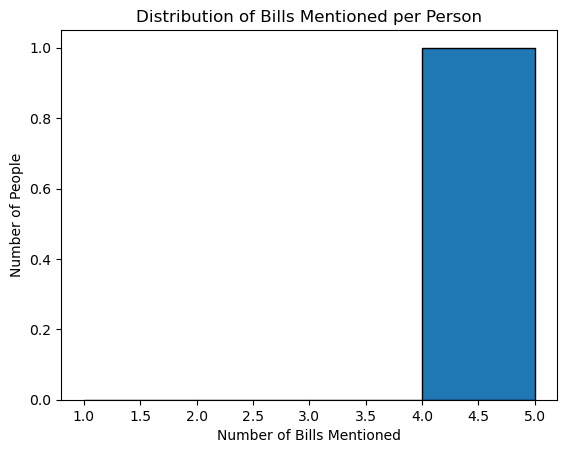

In [10]:
plt.hist(person_counts['bill_count'], bins=range(1, person_counts['bill_count'].max()+2), edgecolor='black')
plt.xlabel("Number of Bills Mentioned")
plt.ylabel("Number of People")
plt.title("Distribution of Bills Mentioned per Person")
plt.show()


In [56]:
# Regex to capture full names
pattern = r'\b(Mr|Ms|Mrs|Miss|Dr)\.?\s+([A-Z][a-z]+(?:-[A-Z][a-z]+)?(?:\s+[A-Z][a-z]+)*)'

senate_bills_house_floor['names'] = senate_bills_house_floor['action'].apply(
    lambda x: [f"{title}. {name}" for title, name in re.findall(pattern, x)] if pd.notnull(x) else []
)

total_names = senate_bills_house_floor['names'].apply(len).sum()
print(f"Total name mentions extracted: {total_names:,}")



Total name mentions extracted: 4


Unique individuals: 2
           person  bill_count
0       Mr. Smith           1
1  Mr. Thornberry           1


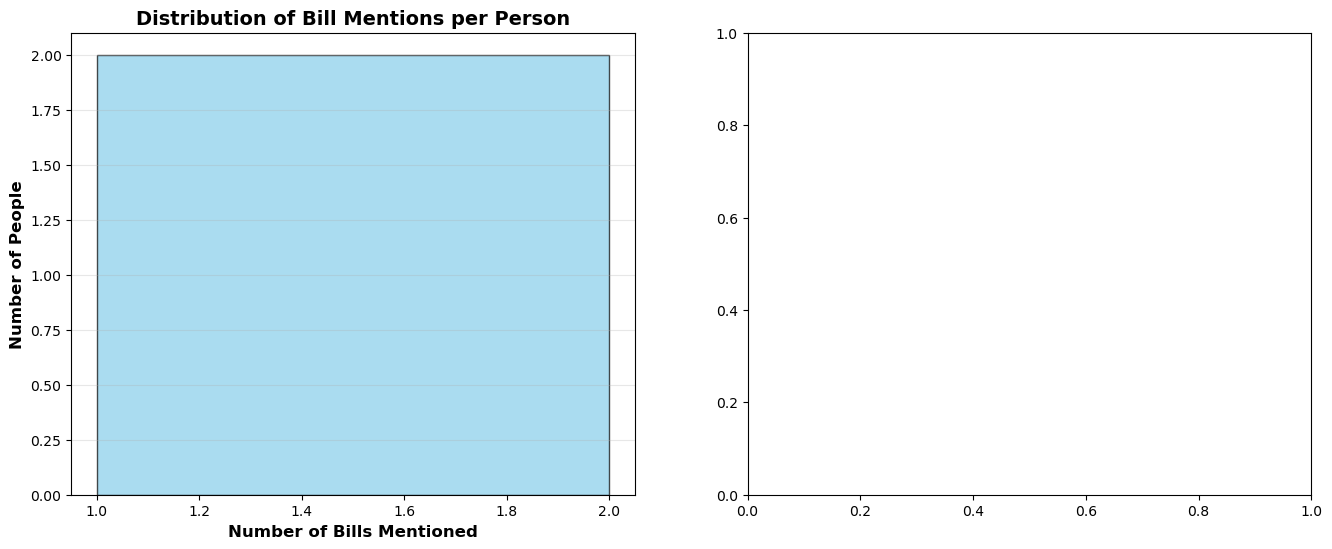

In [58]:
names_exploded = senate_bills_house_floor.explode('names')
names_exploded = names_exploded[names_exploded['names'].notna()].copy()

person_counts = names_exploded.groupby('names')['bill_id'].nunique().reset_index()
person_counts.columns = ['person', 'bill_count']
person_counts = person_counts.sort_values('bill_count', ascending=False)

print(f"Unique individuals: {len(person_counts):,}")
print(person_counts.head(10))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1.hist(person_counts['bill_count'], 
            bins=range(1, person_counts['bill_count'].max() + 2),
            edgecolor='black', color='skyblue', alpha=0.7)
ax1.set_xlabel("Number of Bills Mentioned", fontsize=12, fontweight='bold')
ax1.set_ylabel("Number of People", fontsize=12, fontweight='bold')
ax1.set_title("Distribution of Bill Mentions per Person", fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)




### Find how many mention "senate amendment proposed (on the floor)'

In [61]:
# Filter for "senate amendment proposed (on the floor)" in main_action
amendment_actions = df[df['main_action'].str.contains(
    'senate amendment proposed \(on the floor\)', case=False, na=False
)].copy()

print("Number of bills with 'senate amendment proposed (on the floor)':", len(amendment_actions))


Number of bills with 'senate amendment proposed (on the floor)': 286


### Extract senator names

In [12]:
# Extract all senator mentions per bill
amendment_actions['senators'] = amendment_actions['main_action'].str.findall(r'Senator \S+|Sen\. \S+')

# Count number of senators per bill
amendment_actions['num_senators'] = amendment_actions['senators'].apply(len)

# Assign first and second senator mentioned
amendment_actions['Senator 1'] = amendment_actions['senators'].apply(lambda x: x[0] if len(x) >= 1 else None)
amendment_actions['Senator 2'] = amendment_actions['senators'].apply(lambda x: x[1] if len(x) >= 2 else None)

# Keep relevant columns
senator_dataset = amendment_actions[['main_action', 'num_senators', 'Senator 1', 'Senator 2']]
display(senator_dataset.head(10))


,main_action,num_senators,Senator 1,Senator 2
0,senate amendment proposed (on the floor),0,None,None
1,senate amendment proposed (on the floor),0,None,None
2,senate amendment proposed (on the floor),0,None,None
8,senate amendment proposed (on the floor),0,None,None
11,senate amendment proposed (on the floor),0,None,None
14,senate amendment proposed (on the floor),0,None,None
17,senate amendment proposed (on the floor),0,None,None
18,senate amendment proposed (on the floor),0,None,None
20,senate amendment proposed (on the floor),0,None,None
26,senate amendment proposed (on the floor),0,None,None


In [62]:
def extract_senators(text):
    """Extract senator names using multiple patterns"""
    if pd.isna(text):
        return []
    
    senators = []
    patterns = [
        r'Senator\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)',
        r'Sen\.\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)',
        r'\((?:for\s+)?([A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)\)',
        r'Senator\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)\'s'
    ]
    
    for pattern in patterns:
        matches = re.findall(pattern, text)
        senators.extend(matches)
    
    # Remove duplicates while preserving order
    seen = set()
    unique_senators = []
    for senator in senators:
        senator_cleaned = senator.strip()
        if senator_cleaned and senator_cleaned not in seen:
            seen.add(senator_cleaned)
            unique_senators.append(senator_cleaned)
    
    return unique_senators



In [63]:
# Test extraction
if len(amendment_actions) > 0:
    test_text = amendment_actions['action'].iloc[0]
    print(f"Sample: {test_text[:200]}...")
    print(f"Extracted: {extract_senators(test_text)}")

# Apply extraction
amendment_actions['senators_from_action'] = amendment_actions['action'].apply(extract_senators)
amendment_actions['senators_from_main'] = amendment_actions['main_action'].apply(extract_senators)

amendment_actions['senators'] = amendment_actions.apply(
    lambda row: row['senators_from_action'] if len(row['senators_from_action']) > 0 
    else row['senators_from_main'], axis=1
)

amendment_actions['num_senators'] = amendment_actions['senators'].apply(len)
amendment_actions['Senator 1'] = amendment_actions['senators'].apply(
    lambda x: x[0] if len(x) >= 1 else None
)
amendment_actions['Senator 2'] = amendment_actions['senators'].apply(
    lambda x: x[1] if len(x) >= 2 else None
)




Sample: S.Amdt.1274 Amendment SA 1274 proposed by Senator McConnell for Senator Cornyn. (consideration: CR S7233 ; text: CR S7233 ) In the nature of a substitute....
Extracted: ['Mc', 'Cornyn']


In [64]:
print(f"Total amendments: {len(amendment_actions):,}")
print(f"Amendments with ≥1 senator: {(amendment_actions['num_senators'] > 0).sum():,}")
print(f"Amendments with ≥2 senators: {(amendment_actions['num_senators'] >= 2).sum():,}")
print(f"Success rate: {(amendment_actions['num_senators'] > 0).sum()/len(amendment_actions)*100:.1f}%")

print("Distribution of senator counts:")
senator_dist = amendment_actions['num_senators'].value_counts().sort_index()
for count, freq in senator_dist.items():
    print(f"   {count} senator(s): {freq:,} amendments ({freq/len(amendment_actions)*100:.1f}%)")

print("Sample extractions:")
print(amendment_actions[['bill_id', 'num_senators', 'Senator 1', 'Senator 2']].head(10))


Total amendments: 286
Amendments with ≥1 senator: 286
Amendments with ≥2 senators: 193
Success rate: 100.0%
Distribution of senator counts:
   1 senator(s): 93 amendments (32.5%)
   2 senator(s): 193 amendments (67.5%)
Sample extractions:
   bill_id  num_senators  Senator 1  Senator 2
0    s1029             2         Mc     Cornyn
1    s1031             1     Hawley       None
2    s1160             2         Mc      Smith
8    s1253             2  Feinstein     Cornyn
11   s1309             2         Mc     Cardin
14   s1340             2      Rubio   Menendez
17   s1387             2      Moran      Braun
18   s1434             2         Mc    Portman
20   s1430             2    Fischer   Lankford
26   s1636             2         Mc  Alexander


### Visualize Senator Distribution

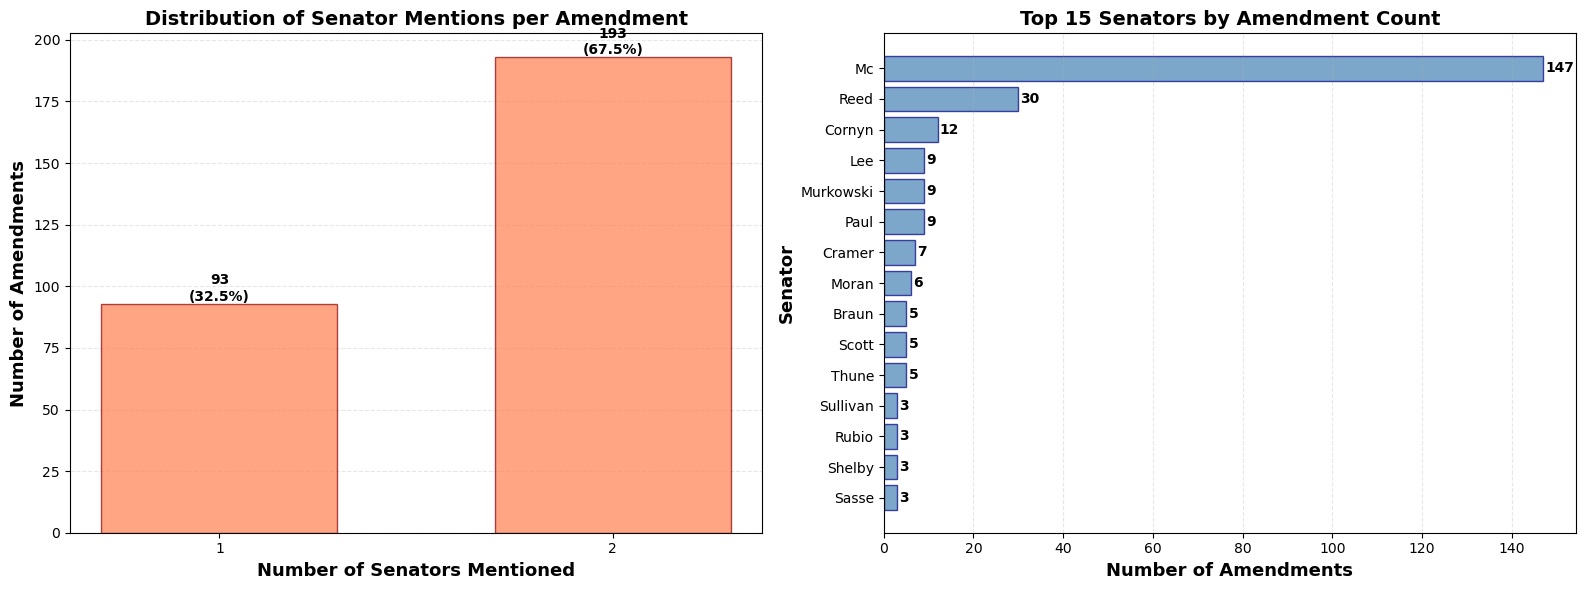

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of senator counts
senator_counts_dist = amendment_actions['num_senators'].value_counts().sort_index()
axes[0].bar(senator_counts_dist.index, senator_counts_dist.values, 
            color='coral', edgecolor='darkred', alpha=0.7, width=0.6)
axes[0].set_xlabel("Number of Senators Mentioned", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Number of Amendments", fontsize=13, fontweight='bold')
axes[0].set_title("Distribution of Senator Mentions per Amendment", fontsize=14, fontweight='bold')
axes[0].set_xticks(range(senator_counts_dist.index.min(), senator_counts_dist.index.max() + 1))
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_axisbelow(True)

for idx, count in zip(senator_counts_dist.index, senator_counts_dist.values):
    axes[0].text(idx, count, f'{count:,}\n({count/len(amendment_actions)*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Top senators
senator1_counts = amendment_actions[amendment_actions['Senator 1'].notna()]['Senator 1'].value_counts().head(15)

if len(senator1_counts) > 0:
    axes[1].barh(range(len(senator1_counts)), senator1_counts.values, 
                 color='steelblue', edgecolor='navy', alpha=0.7)
    axes[1].set_yticks(range(len(senator1_counts)))
    axes[1].set_yticklabels(senator1_counts.index)
    axes[1].set_xlabel("Number of Amendments", fontsize=13, fontweight='bold')
    axes[1].set_ylabel("Senator", fontsize=13, fontweight='bold')
    axes[1].set_title("Top 15 Senators by Amendment Count", fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, v in enumerate(senator1_counts.values):
        axes[1].text(v + 0.5, i, str(v), va='center', fontsize=10, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No senator data extracted', ha='center', va='center', fontsize=14)
    axes[1].axis('off')

plt.tight_layout()
plt.show()


### With how many different people does each Senator 1 coauthor bills

In [69]:
coauthored = amendment_actions[
    (amendment_actions['Senator 1'].notna()) & 
    (amendment_actions['Senator 2'].notna())
].copy()

print(f"Amendments with co-authors: {len(coauthored):,}")
print(f"Percentage: {len(coauthored)/len(amendment_actions)*100:.2f}%")


# Unique co-authors per Senator 1
coauthor_counts = coauthored.groupby('Senator 1')['Senator 2'].nunique().reset_index()
coauthor_counts.columns = ['Senator', 'Unique_Coauthors']
coauthor_counts = coauthor_counts.sort_values('Unique_Coauthors', ascending=False)

print(f"Senators with most unique co-authors:")
print(coauthor_counts.head(10))

# Most common partnerships
partnerships = coauthored.groupby(['Senator 1', 'Senator 2']).size().reset_index(name='count')
partnerships = partnerships.sort_values('count', ascending=False)

print(f"Most frequent partnerships:")
print(partnerships.head(10))

Amendments with co-authors: 193
Percentage: 67.48%
Senators with most unique co-authors:
      Senator  Unique_Coauthors
9          Mc                56
14       Reed                25
1      Cornyn                 9
2      Cramer                 7
12  Murkowski                 6
0       Braun                 5
11      Moran                 4
8         Lee                 3
19      Thune                 3
4     Fischer                 2
Most frequent partnerships:
   Senator 1  Senator 2  count
43        Mc     Cornyn      7
73        Mc     Shelby      5
50        Mc    Gardner      4
33        Mc      Blunt      4
79        Mc      Thune      4
30        Mc  Alexander      4
48        Mc      Ernst      4
61        Mc   Menendez      3
55        Mc     Hoeven      3
56        Mc     Inhofe      3


### Visualization

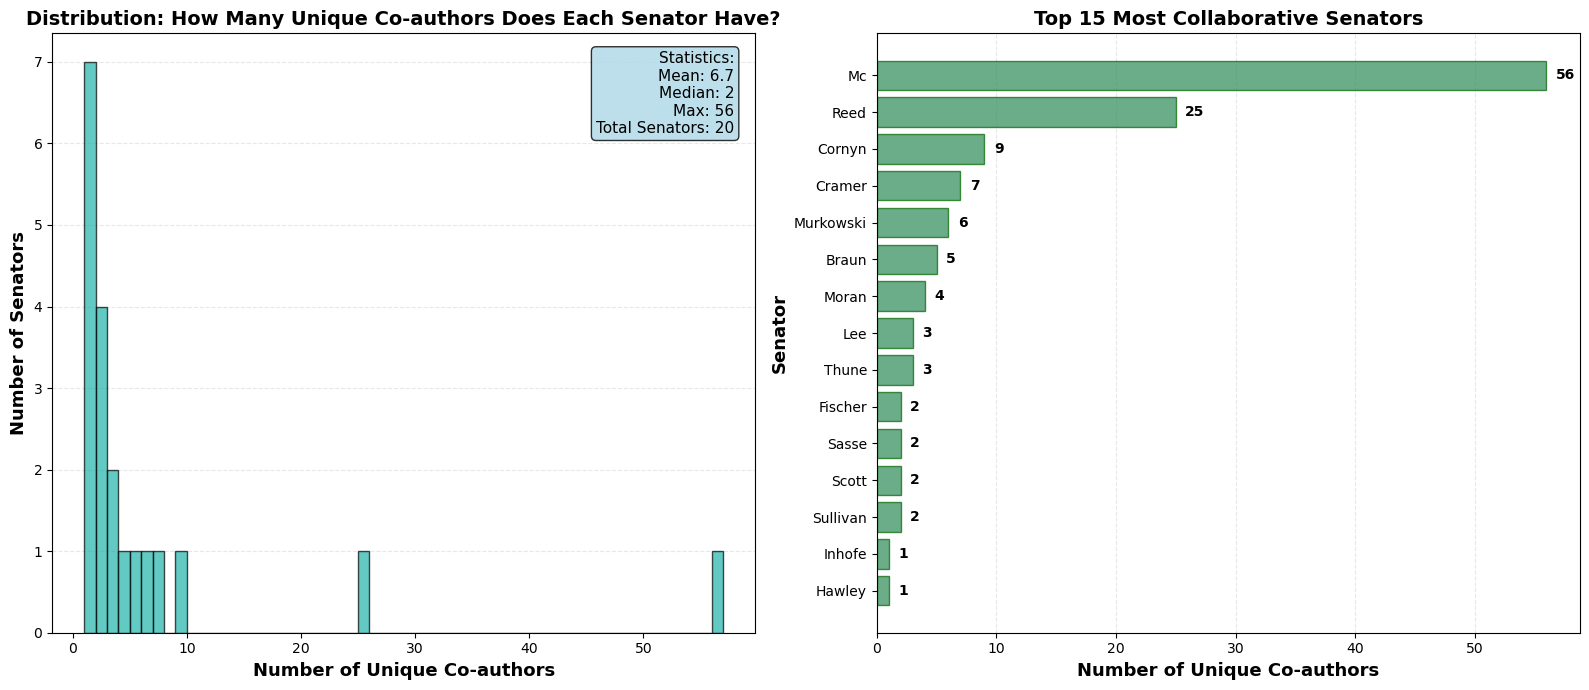

In [73]:
# Visualize co-authorship patterns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Distribution of unique co-authors per senator
ax1.hist(coauthor_counts['Unique_Coauthors'], 
         bins=range(1, coauthor_counts['Unique_Coauthors'].max() + 2),
         edgecolor='black', color='lightseagreen', alpha=0.7)
ax1.set_xlabel("Number of Unique Co-authors", fontsize=13, fontweight='bold')
ax1.set_ylabel("Number of Senators", fontsize=13, fontweight='bold')
ax1.set_title("Distribution: How Many Unique Co-authors Does Each Senator Have?", 
              fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Add statistics box
stats_text = f"""Statistics:
Mean: {coauthor_counts['Unique_Coauthors'].mean():.1f}
Median: {coauthor_counts['Unique_Coauthors'].median():.0f}
Max: {coauthor_counts['Unique_Coauthors'].max()}
Total Senators: {len(coauthor_counts)}"""
ax1.text(0.97, 0.97, stats_text, transform=ax1.transAxes,
         fontsize=11, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Top 15 most collaborative senators
top_15 = coauthor_counts.head(15)
ax2.barh(range(len(top_15)), top_15['Unique_Coauthors'], 
         color='seagreen', edgecolor='darkgreen', alpha=0.7)
ax2.set_yticks(range(len(top_15)))
ax2.set_yticklabels(top_15['Senator'])
ax2.set_xlabel("Number of Unique Co-authors", fontsize=13, fontweight='bold')
ax2.set_ylabel("Senator", fontsize=13, fontweight='bold')
ax2.set_title("Top 15 Most Collaborative Senators", fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add value labels on bars
for i, v in enumerate(top_15['Unique_Coauthors']):
    ax2.text(v + 0.8, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



### Insights

**Legislative Activity**

- This dataset includes 3,303 legislative actions tied to 1,494 distinct bills. Nearly half of all actions are amendments, which shows that most congressional work involves revising and negotiating existing bills rather than passing new ones outright. House bills appear more often than Senate bills, suggesting higher recorded activity in the House.

**Cross-Chamber Activity**

- Very few Senate bill actions reference the House in this dataset. Only four cases mention House floor activity, and none involve suspension procedures. This likely means the data captures early stages of the legislative process before most bills move between chambers.

**Senate Amendment Collaboration**

- There are 286 Senate floor amendments in the data, and most of them involve two senators. This suggests that collaboration is common when proposing amendments. Senator McConnell works with the largest number of different co-authors, which fits with his leadership role during the 116th Congress.

**Methodology**

- Senator names appear in several different formats, so flexible regular expressions were needed to extract them accurately. Composite bill identifiers and basic quality checks were used to keep counts and proportions consistent.

**Conclusion**

- Overall, the results show that amendments are where much of the real legislative work happens. Even in a polarized environment, senators frequently collaborate through the amendment process.